In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn scipy jupyter notebook

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: C:\Users\LENOVO\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


# Personalized Learning Path Recommendation System for Interns

## Objective

The objective of this project is to develop a personalized learning
recommendation system for interns.

The system uses historical intern learning patterns and course metadata
to recommend suitable learning modules to each intern.

## Machine Learning Approach

Collaborative Filtering using Matrix Factorization.

## Expected Outcome

The system will generate personalized learning recommendations for each
intern based on their previous learning interactions and preferences.

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

from scipy.sparse import csr_matrix

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
np.random.seed(42)

interns = [f"I{i:03d}" for i in range(1, 51)]

courses = [f"C{i:03d}" for i in range(1, 21)]

data = []

for intern in interns:
    for course in courses:
        
        # Randomly decide whether intern interacted with course
        if np.random.rand() < 0.55:
            
            rating = np.random.randint(1, 6)
            completion = np.random.choice([0, 1], p=[0.25, 0.75])
            time_spent = np.random.randint(20, 180)
            
            data.append([
                intern,
                course,
                rating,
                completion,
                time_spent
            ])

learning_df = pd.DataFrame(
    data,
    columns=[
        "intern_id",
        "course_id",
        "rating",
        "completion",
        "time_spent"
    ]
)

learning_df.head()

,intern_id,course_id,rating,completion,time_spent
0,I001,C001,5,0,91
1,I001,C003,3,0,107
2,I001,C004,3,0,21
3,I001,C007,4,0,77
4,I001,C008,4,0,78


In [5]:
print("Number of interactions:", len(learning_df))
print("Number of interns:", learning_df["intern_id"].nunique())
print("Number of courses:", learning_df["course_id"].nunique())

Number of interactions: 538
Number of interns: 50
Number of courses: 20


In [6]:
learning_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 538 entries, 0 to 537
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   intern_id   538 non-null    str  
 1   course_id   538 non-null    str  
 2   rating      538 non-null    int64
 3   completion  538 non-null    int64
 4   time_spent  538 non-null    int64
dtypes: int64(3), str(2)
memory usage: 25.3 KB


In [7]:
learning_df.isnull().sum()

intern_id     0
course_id     0
rating        0
completion    0
time_spent    0
dtype: int64

In [8]:
learning_df.describe()

,rating,completion,time_spent
count,538.000000,538.000000,538.000000
mean,3.076208,0.739777,103.211896
std,1.454381,0.439165,47.406634
min,1.000000,0.000000,20.000000
25%,2.000000,0.000000,61.500000
50%,3.000000,1.000000,105.000000
75%,4.000000,1.000000,145.000000
max,5.000000,1.000000,179.000000


In [9]:
course_data = {
    "course_id": courses,
    
    "course_name": [
        "Python Basics",
        "Advanced Python",
        "SQL Fundamentals",
        "Data Visualization",
        "Statistics",
        "Machine Learning Basics",
        "Advanced Machine Learning",
        "Deep Learning",
        "NLP Fundamentals",
        "Computer Vision",
        "Data Structures",
        "Algorithms",
        "Git and GitHub",
        "Cloud Computing",
        "Data Engineering",
        "Power BI",
        "Excel Analytics",
        "Communication Skills",
        "Project Management",
        "Cybersecurity Basics"
    ],
    
    "category": [
        "Programming",
        "Programming",
        "Data",
        "Data",
        "Statistics",
        "AI",
        "AI",
        "AI",
        "AI",
        "AI",
        "Programming",
        "Programming",
        "Tools",
        "Cloud",
        "Data",
        "Analytics",
        "Analytics",
        "Soft Skills",
        "Management",
        "Security"
    ],
    
    "difficulty": [
        "Beginner",
        "Advanced",
        "Beginner",
        "Beginner",
        "Intermediate",
        "Intermediate",
        "Advanced",
        "Advanced",
        "Advanced",
        "Advanced",
        "Intermediate",
        "Intermediate",
        "Beginner",
        "Intermediate",
        "Advanced",
        "Beginner",
        "Beginner",
        "Beginner",
        "Intermediate",
        "Beginner"
    ],
    
    "duration_hours": [
        5, 8, 6, 5, 7, 10, 12, 15, 12, 14,
        8, 10, 4, 10, 14, 6, 5, 4, 8, 7
    ]
}

courses_df = pd.DataFrame(course_data)

courses_df.head()

,course_id,course_name,category,difficulty,duration_hours
0,C001,Python Basics,Programming,Beginner,5
1,C002,Advanced Python,Programming,Advanced,8
2,C003,SQL Fundamentals,Data,Beginner,6
3,C004,Data Visualization,Data,Beginner,5
4,C005,Statistics,Statistics,Intermediate,7


In [11]:
learning_df.to_csv(
    "data/intern_learning.csv",
    index=False
)

courses_df.to_csv(
    "data/courses.csv",
    index=False
)

print("Datasets saved successfully!")

Datasets saved successfully!


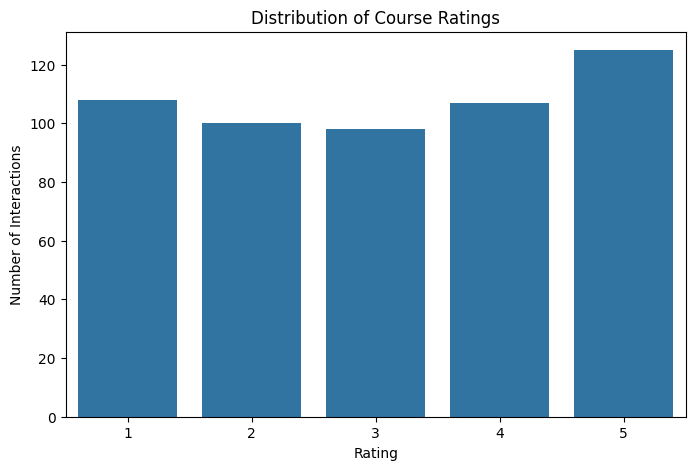

In [12]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=learning_df,
    x="rating"
)

plt.title("Distribution of Course Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Interactions")

plt.show()

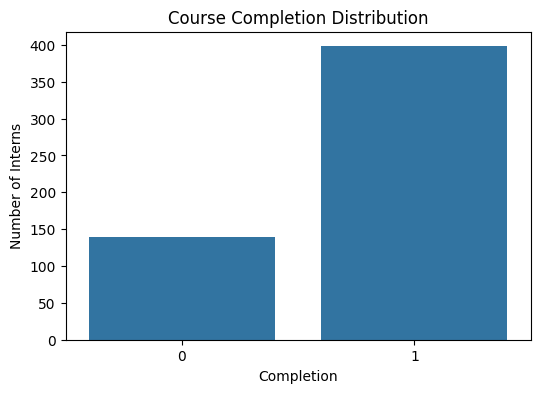

In [13]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=learning_df,
    x="completion"
)

plt.title("Course Completion Distribution")
plt.xlabel("Completion")
plt.ylabel("Number of Interns")

plt.show()

In [14]:
course_ratings = (
    learning_df
    .groupby("course_id")["rating"]
    .mean()
    .sort_values(ascending=False)
)

course_ratings

course_id
C006    3.466667
C004    3.437500
C008    3.391304
C019    3.387097
C001    3.333333
C005    3.259259
C011    3.250000
C017    3.217391
C002    3.190476
C015    3.148148
C020    3.107143
C016    3.080000
C013    3.041667
C007    3.032258
C014    2.952381
C003    2.846154
C012    2.821429
C018    2.766667
C009    2.391304
C010    2.375000
Name: rating, dtype: float64

In [15]:
interaction_matrix = learning_df.pivot_table(
    index="intern_id",
    columns="course_id",
    values="rating",
    fill_value=0
)

interaction_matrix.head()

course_id,C001,C002,C003,C004,C005,C006,C007,C008,C009,C010,C011,C012,C013,C014,C015,C016,C017,C018,C019,C020
intern_id,,,,,,,,,,,,,,,,,,,,
I001,5.0,0.0,3.0,3.0,0.0,0.0,4.0,4.0,4.0,3.0,5.0,2.0,0.0,2.0,4.0,1.0,0.0,2.0,0.0,0.0
I002,0.0,0.0,0.0,4.0,0.0,0.0,2.0,5.0,1.0,3.0,0.0,0.0,2.0,0.0,1.0,0.0,0.0,0.0,3.0,0.0
I003,0.0,0.0,3.0,4.0,0.0,5.0,0.0,5.0,0.0,0.0,0.0,0.0,5.0,4.0,4.0,1.0,3.0,3.0,0.0,1.0
I004,2.0,1.0,5.0,2.0,0.0,0.0,3.0,4.0,0.0,0.0,3.0,0.0,4.0,4.0,1.0,2.0,0.0,0.0,2.0,0.0
I005,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,2.0,5.0,0.0,0.0,4.0,5.0,0.0,0.0,4.0,4.0


In [17]:
print("Matrix shape:", interaction_matrix.shape)

Matrix shape: (50, 20)


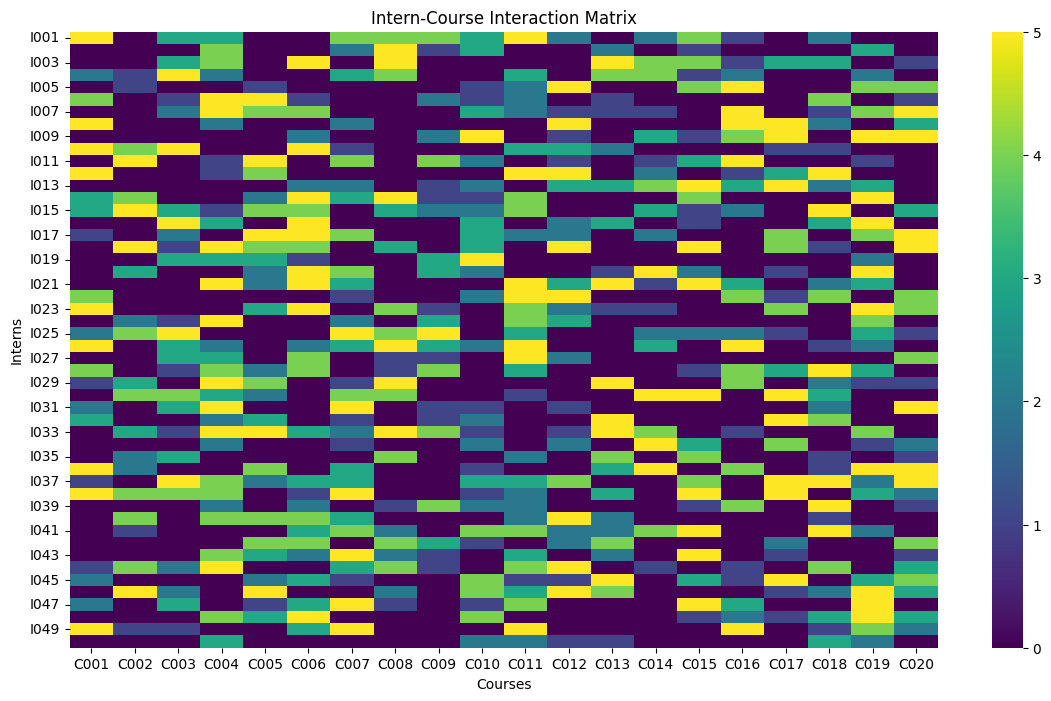

In [18]:
plt.figure(figsize=(14, 8))

sns.heatmap(
    interaction_matrix,
    cmap="viridis"
)

plt.title("Intern-Course Interaction Matrix")
plt.xlabel("Courses")
plt.ylabel("Interns")

plt.show()

In [19]:
intern_ids = interaction_matrix.index.tolist()
course_ids = interaction_matrix.columns.tolist()

intern_to_index = {
    intern: i
    for i, intern in enumerate(intern_ids)
}

course_to_index = {
    course: i
    for i, course in enumerate(course_ids)
}

ratings = interaction_matrix.values

print("Number of interns:", len(intern_ids))
print("Number of courses:", len(course_ids))

Number of interns: 50
Number of courses: 20


In [20]:
observed_interactions = []

for i in range(ratings.shape[0]):
    for j in range(ratings.shape[1]):
        
        if ratings[i, j] > 0:
            observed_interactions.append(
                (i, j, ratings[i, j])
            )

print(
    "Observed interactions:",
    len(observed_interactions)
)

Observed interactions: 538


In [21]:
train_data, test_data = train_test_split(
    observed_interactions,
    test_size=0.2,
    random_state=42
)

print("Training interactions:", len(train_data))
print("Testing interactions:", len(test_data))

Training interactions: 430
Testing interactions: 108


In [22]:
num_interns = len(intern_ids)
num_courses = len(course_ids)

latent_factors = 10

np.random.seed(42)

U = np.random.normal(
    0,
    0.1,
    (num_interns, latent_factors)
)

V = np.random.normal(
    0,
    0.1,
    (num_courses, latent_factors)
)

intern_bias = np.zeros(num_interns)
course_bias = np.zeros(num_courses)

global_mean = np.mean(
    [rating for _, _, rating in train_data]
)

print("Global mean rating:", global_mean)

Global mean rating: 3.0534883720930233


In [23]:
learning_rate = 0.01
regularization = 0.02
epochs = 100

for epoch in range(epochs):
    
    np.random.shuffle(train_data)
    
    total_error = 0
    
    for i, j, actual_rating in train_data:
        
        prediction = (
            global_mean
            + intern_bias[i]
            + course_bias[j]
            + np.dot(U[i], V[j])
        )
        
        error = actual_rating - prediction
        
        total_error += error ** 2
        
        # Update biases
        intern_bias[i] += learning_rate * (
            error - regularization * intern_bias[i]
        )
        
        course_bias[j] += learning_rate * (
            error - regularization * course_bias[j]
        )
        
        # Save current latent factors
        user_factors = U[i].copy()
        course_factors = V[j].copy()
        
        # Update latent factors
        U[i] += learning_rate * (
            error * course_factors
            - regularization * user_factors
        )
        
        V[j] += learning_rate * (
            error * user_factors
            - regularization * course_factors
        )
    
    rmse = np.sqrt(
        total_error / len(train_data)
    )
    
    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch + 1}/{epochs} - "
            f"RMSE: {rmse:.4f}"
        )

Epoch 10/100 - RMSE: 1.3531
Epoch 20/100 - RMSE: 1.2460
Epoch 30/100 - RMSE: 1.0252
Epoch 40/100 - RMSE: 0.7836
Epoch 50/100 - RMSE: 0.5941
Epoch 60/100 - RMSE: 0.4449
Epoch 70/100 - RMSE: 0.3378
Epoch 80/100 - RMSE: 0.2689
Epoch 90/100 - RMSE: 0.2242
Epoch 100/100 - RMSE: 0.1931


In [24]:
def predict_rating(intern_index, course_index):
    
    prediction = (
        global_mean
        + intern_bias[intern_index]
        + course_bias[course_index]
        + np.dot(
            U[intern_index],
            V[course_index]
        )
    )
    
    return prediction

In [25]:
actuals = []
predictions = []

for i, j, actual_rating in test_data:
    
    prediction = predict_rating(i, j)
    
    actuals.append(actual_rating)
    predictions.append(prediction)

rmse = np.sqrt(
    mean_squared_error(
        actuals,
        predictions
    )
)

mae = mean_absolute_error(
    actuals,
    predictions
)

print("RMSE:", round(rmse, 4))
print("MAE:", round(mae, 4))

RMSE: 1.8957
MAE: 1.5373


In [26]:
def recommend_courses(
    intern_id,
    top_n=5
):
    
    if intern_id not in intern_to_index:
        return "Intern not found."
    
    intern_index = intern_to_index[intern_id]
    
    recommendations = []
    
    for course_id, course_index in course_to_index.items():
        
        # Skip courses already taken
        if ratings[intern_index, course_index] > 0:
            continue
        
        predicted_rating = predict_rating(
            intern_index,
            course_index
        )
        
        recommendations.append(
            (
                course_id,
                predicted_rating
            )
        )
    
    recommendations.sort(
        key=lambda x: x[1],
        reverse=True
    )
    
    return recommendations[:top_n]

In [27]:
recommend_courses(
    "I001",
    top_n=5
)

[('C002', np.float64(4.761453923060671)),
 ('C013', np.float64(4.632654349712027)),
 ('C005', np.float64(4.3939419419148695)),
 ('C020', np.float64(3.2948966472267265)),
 ('C006', np.float64(3.194085659484356))]

In [28]:
def get_recommendations(
    intern_id,
    top_n=5
):
    
    recommendations = recommend_courses(
        intern_id,
        top_n
    )
    
    if isinstance(recommendations, str):
        return recommendations
    
    recommendation_df = pd.DataFrame(
        recommendations,
        columns=[
            "course_id",
            "predicted_rating"
        ]
    )
    
    recommendation_df = recommendation_df.merge(
        courses_df,
        on="course_id",
        how="left"
    )
    
    recommendation_df = recommendation_df[
        [
            "course_id",
            "course_name",
            "category",
            "difficulty",
            "duration_hours",
            "predicted_rating"
        ]
    ]
    
    return recommendation_df

In [29]:
get_recommendations(
    "I001",
    top_n=5
)

,course_id,course_name,category,difficulty,duration_hours,predicted_rating
0,C002,Advanced Python,Programming,Advanced,8,4.761454
1,C013,Git and GitHub,Tools,Beginner,4,4.632654
2,C005,Statistics,Statistics,Intermediate,7,4.393942
3,C020,Cybersecurity Basics,Security,Beginner,7,3.294897
4,C006,Machine Learning Basics,AI,Intermediate,10,3.194086
